# Task 05：Policy Gradient——学习与实验入口

## 本 Notebook 的学习边界

策略梯度直接优化 $\pi_	heta(a\mid s)$。REINFORCE 的单轨迹目标可写为：

$$

abla_	heta J(	heta)pprox\sum_t G_t
abla_	heta\log\pi_	heta(A_t\mid S_t).
$$

先理解 policy network 和采样，再运行 vanilla REINFORCE，随后加入 value baseline，最后用多个 seed 比较均值、方差和达到阈值所需 episode 数。


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append("../src")

from reinforce_baseline import (
    train_reinforce_baseline,
    evaluate_policy,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
env = gym.make("CartPole-v1")

policy, value_net, history = train_reinforce_baseline(
    env=env,
    num_episodes=1000,
    gamma=0.99,
    policy_lr=1e-3,
    value_lr=1e-3,
    hidden_dim=128,
    seed=42,
    print_interval=50,
)

Episode   50 | Return  116.0 | Avg Return   38.08 | Policy Loss  21.7140 | Value Loss 396.4654
Episode  100 | Return   38.0 | Avg Return   97.42 | Policy Loss  -6.8505 | Value Loss 835.6807
Episode  150 | Return  121.0 | Avg Return  163.06 | Policy Loss  -1.2010 | Value Loss 975.2902
Episode  200 | Return  119.0 | Avg Return  181.50 | Policy Loss   1.1883 | Value Loss 591.1442
Episode  250 | Return  240.0 | Avg Return  227.58 | Policy Loss  -1.0650 | Value Loss 466.0616
Episode  300 | Return  183.0 | Avg Return  304.36 | Policy Loss  -4.6935 | Value Loss 392.2251
Episode  350 | Return  294.0 | Avg Return  380.50 | Policy Loss   2.1409 | Value Loss 296.3759
Episode  400 | Return  438.0 | Avg Return  399.12 | Policy Loss   5.6989 | Value Loss 334.9350
Episode  450 | Return  477.0 | Avg Return  398.66 | Policy Loss   4.5613 | Value Loss 233.9563
Episode  500 | Return  413.0 | Avg Return  484.16 | Policy Loss  -0.8093 | Value Loss 470.4372
Episode  550 | Return  294.0 | Avg Return  432.56 

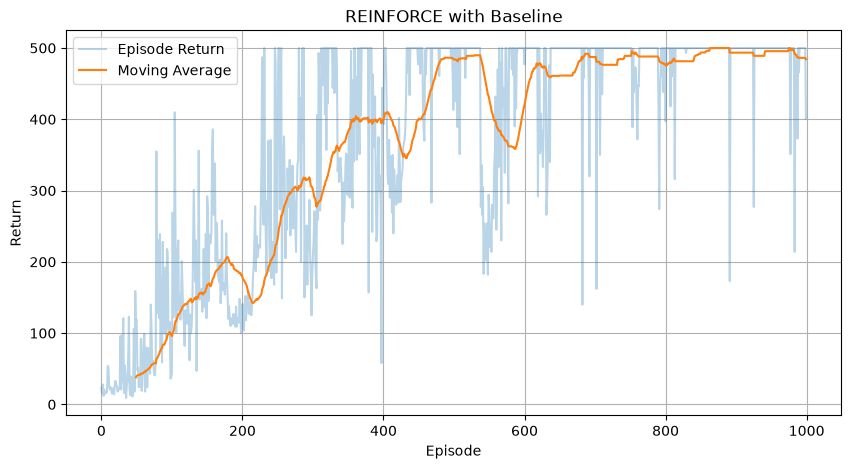

In [4]:
returns = np.array(history["episode_returns"])

window = 50

moving_avg = np.convolve(
    returns,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(10, 5))

plt.plot(
    returns,
    alpha=0.3,
    label="Episode Return",
)

plt.plot(
    np.arange(window - 1, len(returns)),
    moving_avg,
    label="Moving Average",
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("REINFORCE with Baseline")
plt.legend()
plt.grid()

plt.show()

In [5]:
result = evaluate_policy(
    env=env,
    policy_network=policy,
    num_episodes=20,
    deterministic=True,
)

print("Mean Return:", result["mean_return"])
print("Std Return:", result["std_return"])

Mean Return: 500.0
Std Return: 0.0


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
